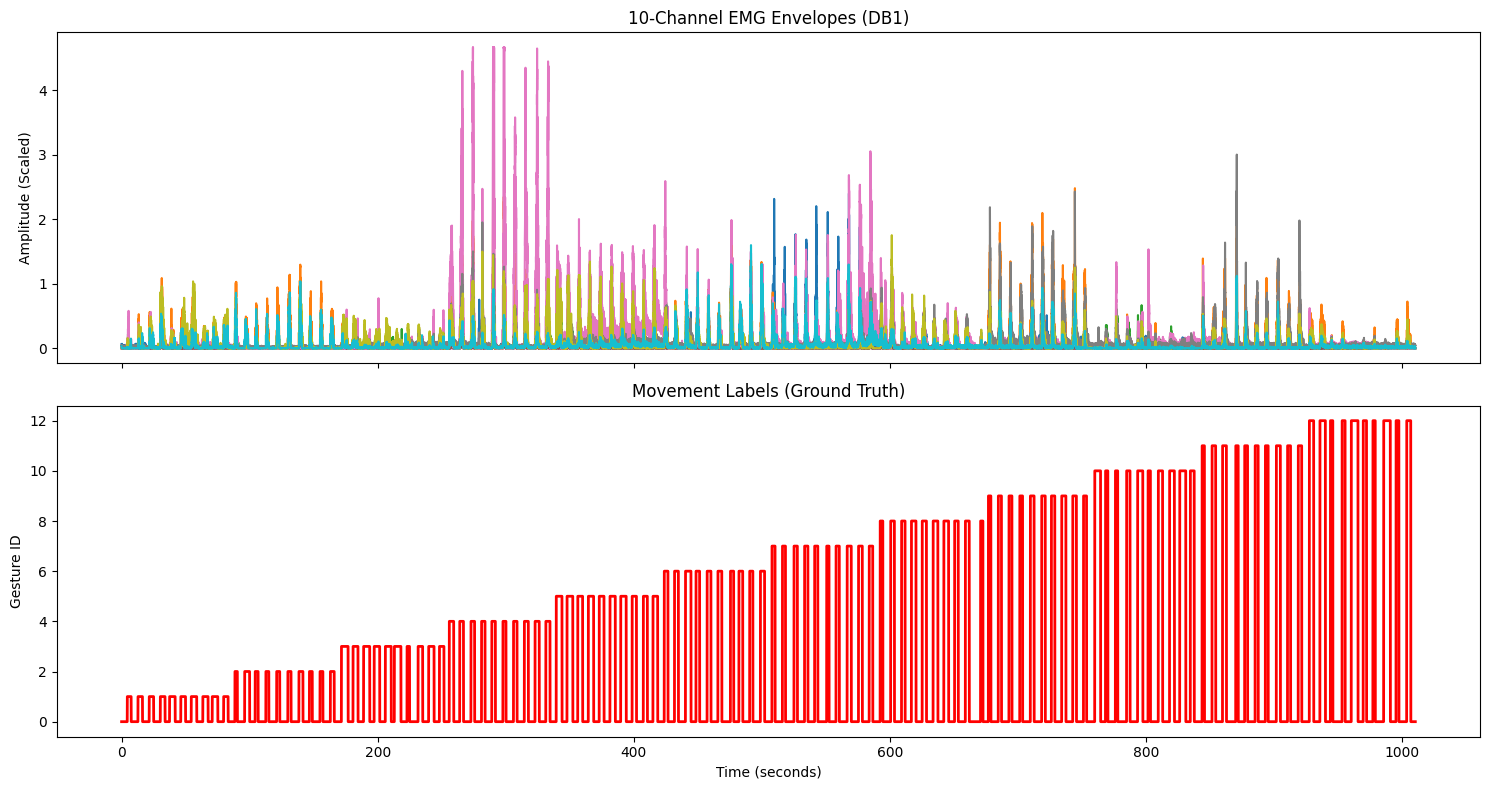

In [5]:
# Loading .mat files and visualization
import scipy.io as sio
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# 1. Load the data
current_folder = Path.cwd()
project_root = current_folder.parent
data_path = project_root / "data" / "S1_A1_E1.mat"

data = sio.loadmat(data_path)

# 2. Extract key variables
emg = data['emg']            # The 10-channel EMG signal
labels = data['restimulus']  # The gesture IDs (0 to 52)
reps = data['repetition']    # Which repetition (1-10) it belongs to

# 3. Create a time axis (DB1 is sampled at 100Hz)
time = np.linspace(0, len(emg) / 100, len(emg))

# 4. Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Plot all 10 EMG channels
ax1.plot(time, emg)
ax1.set_title('10-Channel EMG Envelopes (DB1)')
ax1.set_ylabel('Amplitude (Scaled)')

# Plot the Gesture Labels
ax2.plot(time, labels, color='red', linewidth=2)
ax2.set_title('Movement Labels (Ground Truth)')
ax2.set_ylabel('Gesture ID')
ax2.set_xlabel('Time (seconds)')

plt.tight_layout()
plt.show()

In [4]:
# Normalization via min-max scaling. TCNs use activation functions like ReLU or Tanh. 
# If your EMG values are large (e.g., 0 to 500), the math inside the network will "explode" (gradients become too large), or the neurons will "saturate" and stop learning.

from sklearn.preprocessing import MinMaxScaler

# 1. Identify your Training and Testing splits based on repetitions
# Example: Train on Reps 1, 3, 4, 6, 8, 9; Test on 2, 5, 7, 10
train_mask = np.isin(reps, [1, 3, 4, 6, 8, 9]).flatten()
test_mask = np.isin(reps, [2, 5, 7, 10]).flatten()

emg_train = emg[train_mask]
emg_test = emg[test_mask]

# 2. Initialize and Fit the Scaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit only on training data
scaler.fit(emg_train)

# 3. Transform both sets
emg_train_norm = scaler.transform(emg_train)
emg_test_norm = scaler.transform(emg_test)

print(f"Normalized Range: {emg_train_norm.min()} to {emg_train_norm.max()}")

Normalized Range: 0.0 to 1.0000000000000002


In [6]:
# A TCN cannot process a single point in time to recognize a gesture; it needs to see a sequence.
# The 2D Structure: The TCN "slides" its filters across the time dimension of your window.

# Window Length (W): 20 samples (200ms). This is long enough to capture the "intent" of a muscle contraction.

# Step Size (S): 10 samples (100ms). This creates a 50% overlap, which gives us more training data and smoother transitions between gestures.
def create_windows(data, labels, window_size=20, step_size=10):
    n_samples = data.shape[0]
    n_channels = data.shape[1]
    
    windows = []
    window_labels = []
    
    for i in range(0, n_samples - window_size, step_size):
        # Extract the window
        window = data[i : i + window_size, :]
        
        # For the label, we usually take the most frequent label in that window (the Mode)
        # or simply the label at the very end of the window.
        label = labels[i + window_size - 1] 
        
        windows.append(window)
        window_labels.append(label)
        
    return np.array(windows), np.array(window_labels)

# Apply it to your data
X_train_raw, y_train = create_windows(emg_train_norm, labels[train_mask])
X_test_raw, y_test = create_windows(emg_test_norm, labels[test_mask])

print(f"Training shape: {X_train_raw.shape}") 
# Expected: (Number of Windows, 20 samples, 10 channels)
# Data is now structured in a 3D tensor [Windows,Time,Features]

Training shape: (3715, 20, 10)


In [7]:
import torch
from torch.utils.data import DataLoader, TensorDataset

# 1. Reshape to (Batch, Channels, Time) -> (3715, 10, 20)
X_train_tcn = np.transpose(X_train_raw, (0, 2, 1))
X_test_tcn = np.transpose(X_test_raw, (0, 2, 1))

# 2. Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train_tcn, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long).squeeze()

X_test_tensor = torch.tensor(X_test_tcn, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).squeeze()

# 3. Create a DataLoader (to feed the model in small bites)
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), 
                          batch_size=64, shuffle=True) # Shuffling is essential for preventing the model to just memorize the order of data
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), 
                         batch_size=64, shuffle=False) # Shuffling would break the alignment between the y labels and the predicted x

In [8]:
# Defining the TCN model: A TCN is essentially a stack of Residual Blocks. Each block uses a larger Dilation to see further back in time.
import torch
import torch.nn as nn

class TCN(nn.Module):
    def __init__(self, num_inputs, num_channels, kernel_size=3, dropout=0.2):
        super(TCN, self).__init__()
        layers = []
        num_levels = len(num_channels)
        
        for i in range(num_levels):
            dilation_size = 2 ** i  # 1, 2, 4, 8...
            in_ch = num_inputs if i == 0 else num_channels[i-1]
            out_ch = num_channels[i]
            
            # Simple version of a TCN layer
            layers += [
                nn.Conv1d(in_ch, out_ch, kernel_size, 
                          stride=1, padding=(kernel_size-1) * dilation_size, 
                          dilation=dilation_size),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]

        self.network = nn.Sequential(*layers)
        self.linear = nn.Linear(num_channels[-1], 53) # 53 classes

    def forward(self, x):
        # x shape: (Batch, 10, 20)
        y = self.network(x)
        # We only care about the very last output of the sequence
        return self.linear(y[:, :, -1])

# Initialize: 10 inputs, layers with [64, 64, 64] filters
model = TCN(num_inputs=10, num_channels=[64, 64, 64])

In [17]:
# Training loop: In the ESN, we just did one fit(). In PyTorch, we loop through the data multiple times (Epochs), gradually lowering the error (Loss).
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
# 2. Add a scheduler that drops the learning rate when progress stalls
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=10, factor=0.5)
criterion = nn.CrossEntropyLoss()

train_losses = [] # Create a loss list for each epoch

for epoch in range(150): # Run 50 times
    model.train()
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()      # Clear old gradients
        output = model(batch_x)    # Forward pass
        loss = criterion(output, batch_y) # Calculate error
        loss.backward()            # Calculate gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Prevents a single error from altering the weights
        optimizer.step()           # Update weights

    scheduler.step(loss.detach().item()) # Tell the scheduler the current loss. detach() moves the loss value to the CPU
    
    train_losses.append(loss.item()) # After the batch loop, save the average loss for the epoch

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.1265
Epoch 10, Loss: 0.2637
Epoch 20, Loss: 0.1622
Epoch 30, Loss: 0.1756
Epoch 40, Loss: 0.0534
Epoch 50, Loss: 0.4430
Epoch 60, Loss: 0.8044
Epoch 70, Loss: 0.1174
Epoch 80, Loss: 1.0036
Epoch 90, Loss: 0.4322
Epoch 100, Loss: 0.0820
Epoch 110, Loss: 1.2398
Epoch 120, Loss: 0.0222
Epoch 130, Loss: 0.0939
Epoch 140, Loss: 2.1689


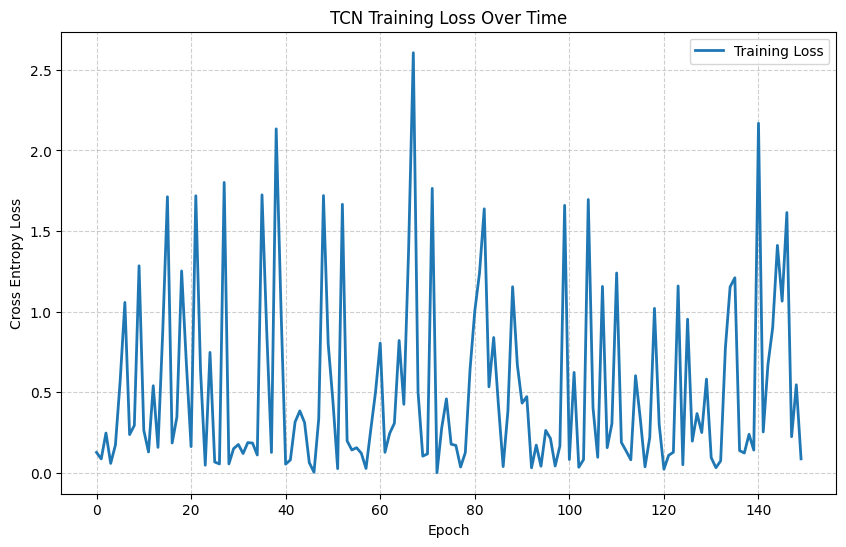

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', color='#1f77b4', linewidth=2)

# Optional: Add a marker for that spike at Epoch 10 you noticed
# plt.annotate('Loss Spike', xy=(10, train_losses[10]), xytext=(30, train_losses[10]+0.5),
#              arrowprops=dict(facecolor='black', shrink=0.05))

plt.title('TCN Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

In [12]:
# The Evaluation Script
# You'll need to run your test data through the model without calculating gradients (which saves memory and prevents accidental learning from the test set).

model.eval()  # Set the model to evaluation mode
all_preds = []
all_labels = []

with torch.no_grad():  # Disable gradient calculation
    for batch_x, batch_y in test_loader:
        # Forward pass
        output = model(batch_x)
        
        # Get the index of the highest value (the predicted class)
        _, preds = torch.max(output, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

from sklearn.metrics import accuracy_score, confusion_matrix
accuracy = accuracy_score(all_labels, all_preds)
print(f"TCN Test Accuracy: {accuracy * 100:.2f}%")

TCN Test Accuracy: 77.59%


In [13]:
# Per-Class F-1 score: Since NinaPro is often imbalanced, accuracy can be deceiving. Check the F1-Score for the harder gestures (like finger movements 9–11).
from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.80      0.92      0.86       981
           1       0.73      0.77      0.75       159
           2       0.96      0.73      0.83       125
           3       0.61      0.80      0.69       128
           4       0.86      0.82      0.84       117
           5       0.82      0.83      0.82       162
           6       0.73      0.51      0.60       119
           7       0.81      0.85      0.83       103
           8       0.69      0.62      0.65       112
           9       0.63      0.55      0.59       106
          10       0.93      0.67      0.78       122
          11       0.59      0.55      0.57       101
          12       0.78      0.39      0.52       142

    accuracy                           0.78      2477
   macro avg       0.76      0.69      0.72      2477
weighted avg       0.78      0.78      0.77      2477



In [15]:
# Wrap your output in a softmax to see probabilities. You can check if the model is "sure" about its wrong answers or if it's "confused" between two similar gestures.
probabilities = torch.nn.functional.softmax(output, dim=1)
print(probabilities)

tensor([[9.6023e-01, 6.4960e-03, 1.2695e-02,  ..., 2.0337e-12, 2.0225e-12,
         2.6041e-12],
        [9.5164e-01, 7.3210e-03, 1.3266e-02,  ..., 2.4274e-11, 2.3885e-11,
         2.9311e-11],
        [9.1005e-01, 9.2598e-03, 1.6006e-03,  ..., 1.9685e-10, 1.9955e-10,
         2.3925e-10],
        ...,
        [9.5843e-01, 7.4539e-03, 1.8095e-02,  ..., 9.9251e-14, 9.6958e-14,
         1.2925e-13],
        [9.5396e-01, 6.4813e-03, 1.2032e-02,  ..., 4.6920e-11, 4.6243e-11,
         5.3795e-11],
        [9.5782e-01, 6.0756e-03, 1.1371e-02,  ..., 1.6967e-11, 1.6921e-11,
         2.0440e-11]])


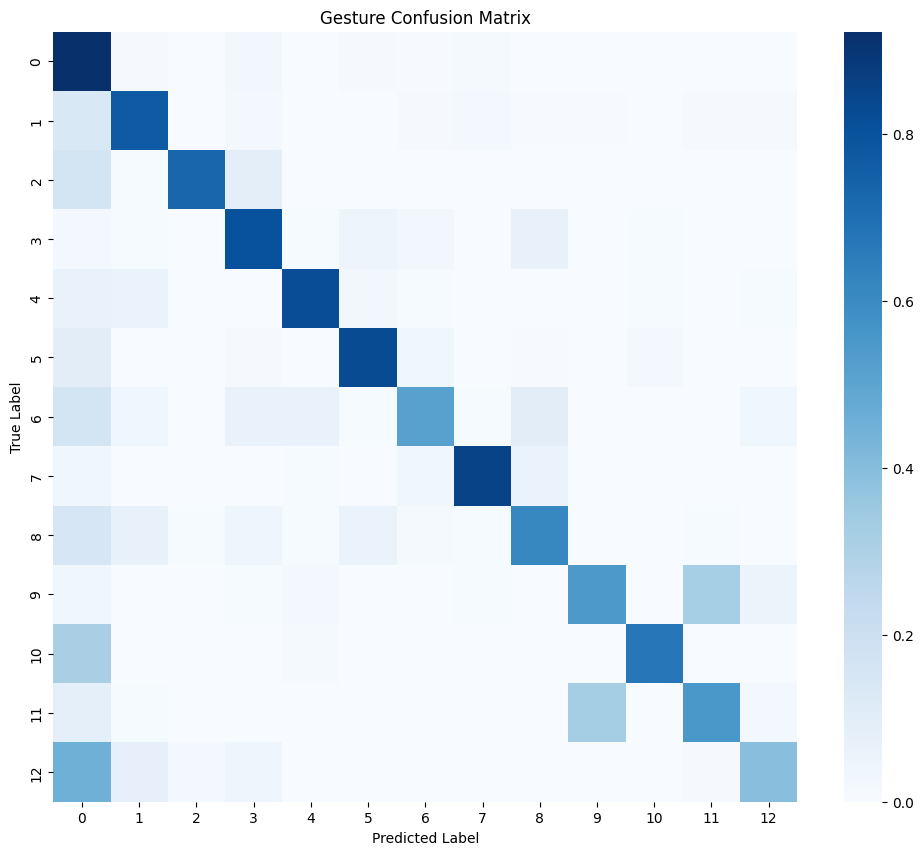

In [14]:
# Confusion matrix: diagnosis method to see if the model is conflating different gestures
# Strong Diagonal: Means the model is getting it right.
# Off-diagonal "Clusters": If you see a bright square away from the diagonal, it means the TCN is confusing two similar gestures (e.g., "Index Finger Extension" vs. "Middle Finger Extension"). 
# To fix this, you would need to increase the Spectral Radius to give the model more "fine-grained" memory.

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
# Normalization (to see percentages instead of raw window counts)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized, annot=False, cmap='Blues', fmt='.2f')
plt.title('Gesture Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [16]:
#Deep Dive: Classification Report

# If you want to see exactly which gestures are dragging down your average, run this to get a per-gesture breakdown:
from sklearn.metrics import classification_report

# This will show Precision, Recall, and F1-score for EVERY gesture
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.80      0.92      0.86       981
           1       0.73      0.77      0.75       159
           2       0.96      0.73      0.83       125
           3       0.61      0.80      0.69       128
           4       0.86      0.82      0.84       117
           5       0.82      0.83      0.82       162
           6       0.73      0.51      0.60       119
           7       0.81      0.85      0.83       103
           8       0.69      0.62      0.65       112
           9       0.63      0.55      0.59       106
          10       0.93      0.67      0.78       122
          11       0.59      0.55      0.57       101
          12       0.78      0.39      0.52       142

    accuracy                           0.78      2477
   macro avg       0.76      0.69      0.72      2477
weighted avg       0.78      0.78      0.77      2477

